In [1]:
#!pip install pandas astroquery astropy numpy matplotlib scipy

In [2]:
import sys
sys.path.append('../gaiadr3_analysis')

import gaia_input as gi
import mean_photometry as mphot
import epoch_photometry as ephot

In [3]:
#df = gi.get_dataframe()
"""
SELECT     source_id, ruwe, ra, dec, pmra, pmdec, parallax, phot_g_mean_mag, phot_bp_mean_mag, phot_rp_mean_mag,  bp_rp FROM gaiadr3.gaia_source WHERE source_id IN (     4146594906281066368,     418001477279154304,     181233674136088960,     3211026372078082048,     3220757015623151616,     3017360348171372672,     3209634905754969856,     3017364063330718080,     3017367396223983616,     3216486478101981056,     3224479171721217280,     3217413606922372992,     3326710010525962624,     2922367976673391232,     5517239366958299776,     5513811055342280448,     817013387993056640,     5338490937045044096,     5336220823491735680,     3667302325846472320,     6116497702589633152,     6005290206037557760,     6044420729667868928,     4371780385208211584,     6730764715540788352,     2032810465079954944,     2059130368252069888,     2270245431209611776,     2272185759996420992,     1796736625538995072,     3131334452194616192 )
"""

'\nSELECT     source_id, ruwe, ra, dec, pmra, pmdec, parallax, phot_g_mean_mag, phot_bp_mean_mag, phot_rp_mean_mag,  bp_rp FROM gaiadr3.gaia_source WHERE source_id IN (     4146594906281066368,     418001477279154304,     181233674136088960,     3211026372078082048,     3220757015623151616,     3017360348171372672,     3209634905754969856,     3017364063330718080,     3017367396223983616,     3216486478101981056,     3224479171721217280,     3217413606922372992,     3326710010525962624,     2922367976673391232,     5517239366958299776,     5513811055342280448,     817013387993056640,     5338490937045044096,     5336220823491735680,     3667302325846472320,     6116497702589633152,     6005290206037557760,     6044420729667868928,     4371780385208211584,     6730764715540788352,     2032810465079954944,     2059130368252069888,     2270245431209611776,     2272185759996420992,     1796736625538995072,     3131334452194616192 )\n'

In [4]:
source_ids = (
4146594906281066368, 418001477279154304, 181233674136088960,
3211026372078082048, 3220757015623151616, 3017360348171372672,
3209634905754969856, 3017364063330718080, 3017367396223983616,
3216486478101981056, 3224479171721217280, 3217413606922372992,
3326710010525962624, 2922367976673391232, 5517239366958299776,
5513811055342280448, 817013387993056640, 5338490937045044096,
5336220823491735680, 3667302325846472320, 6116497702589633152,
6005290206037557760, 6044420729667868928, 4371780385208211584,
6730764715540788352, 2032810465079954944, 2059130368252069888,
2270245431209611776, 2272185759996420992, 1796736625538995072,
3131334452194616192
)

id_list = ", ".join(str(s) for s in source_ids)

adql = f"""
SELECT source_id, designation, ra, dec, parallax,
pmra, pmdec, phot_g_mean_mag, phot_bp_mean_mag,
phot_rp_mean_mag
FROM gaiadr3.gaia_source
WHERE source_id IN ({id_list})
"""

df = gi.query_by_adql(adql)
print(f"Retrieved {len(df)} stars")
df.head()

Retrieved 31 stars


,source_id,designation,ra,dec,parallax,pmra,pmdec,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag
0,5338490937045044096,Gaia DR3 5338490937045044096,166.524167,-59.949865,2.157248,-10.210750,3.200785,6.669657,6.582181,6.798117
1,817013387993056640,Gaia DR3 817013387993056640,138.450704,43.217689,5.268664,-30.236426,-32.032132,5.241456,5.199314,5.340267
2,4371780385208211584,Gaia DR3 4371780385208211584,269.076645,0.670352,3.544555,-4.997440,-0.369024,5.774477,5.810996,5.652102
3,3667302325846472320,Gaia DR3 3667302325846472320,213.065666,2.409310,13.228111,-42.904556,-26.792411,4.961365,4.911909,5.030709
4,418001477279154304,Gaia DR3 418001477279154304,9.242984,53.896868,6.665666,17.444071,-9.522631,3.664362,3.552869,3.813564


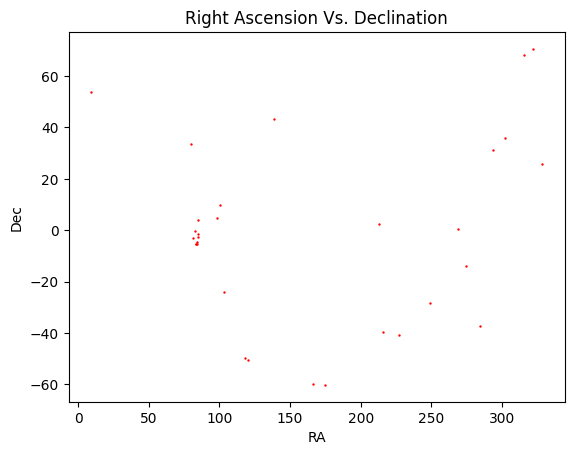

In [5]:
mphot.ra_vs_dec(df)

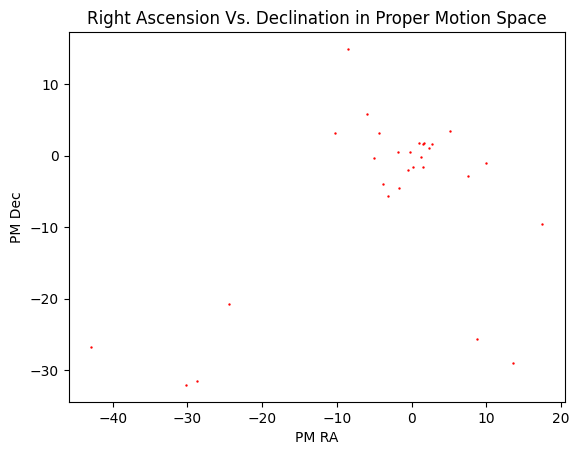

In [6]:
mphot.pmra_vs_pmdec(df)

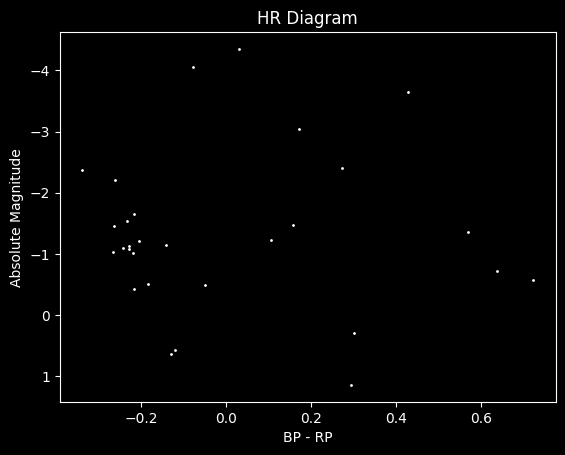

31


In [7]:
mphot.plot_hr_diagram(df)
print(len(df))

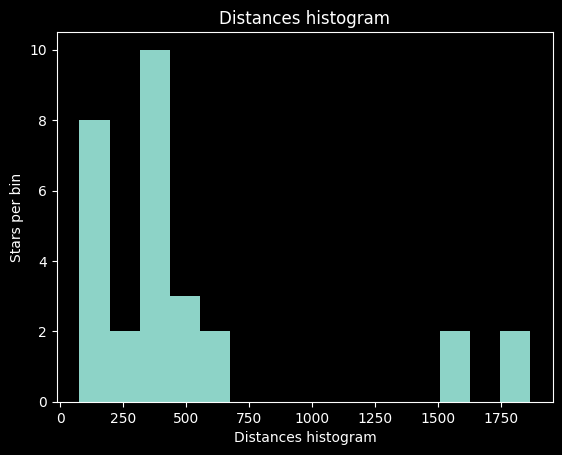

Distances histogram, meidian: 392.72490131328766
Standard Deviation: 502.2500409557288


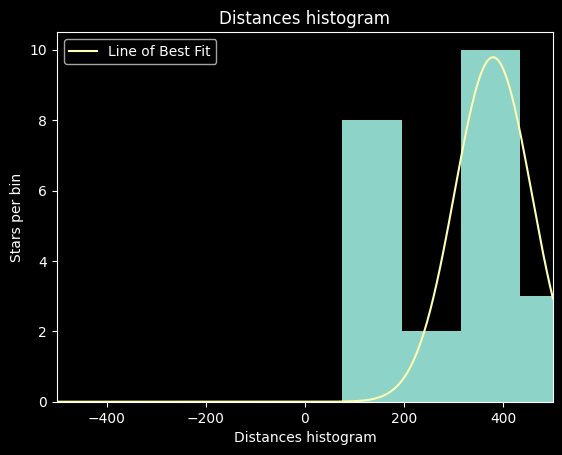

In [8]:
"""
You dont need to copy and paste these, just call mphot.hist or mpoht.fittedHist

def hist(dists, bin_num, parallax=False):
    #Magnitude, Y-Values

    #Adjust if dist given in parallax
    if parallax:
        dists = (1000/parallax)

    plt.title("Distances of Stars in Sample Histogram")
    plt.hist(dists, bins=bin_num)

    plt.xlabel('Distance (pc)')
    plt.ylabel('Stars per bin')
    plt.show()

def gaussian(x, A, sigma, mu):
    return A*(1/(sigma * np.sqrt(2*np.pi)) * np.exp(-1*(x - mu)**2 / (2*sigma**2)))

def fittedHist(dists, bin_num=50, range=[-500,500],parallax=False):
    #Magnitude, Y-Values
    if parallax:
        dists = (1000/parallax)

    median = dists.median()
    std = dists.std()

    print("name"+": "+ str(median))
    plt.title("Starcount Histogram: "+ "name")

    h_1d_output = plt.hist(dists, bins=bin_num)
    x_plot = np.linspace(range[0],range[1], 300)
    x_1d_fit = (h_1d_output[1][:-1]+h_1d_output[1][1:])/2
    y_1d_fit = h_1d_output[0]
    fit = curve_fit(gaussian, x_1d_fit, y_1d_fit, p0 = [55, std, median])
    print("Standard Deviation: "+str(dists.std()))

    #Fix printing this
    #print(fit)
    plt.plot(x_plot, gaussian(x_plot, *fit[0]), label ='Line of Best Fit')

    plt.xlim(range[0], range[1])
    plt.xlabel('Distance (pc)')
    plt.ylabel('Stars per bin')
    plt.legend()
    plt.show()
"""
#dists = (1000/df["parallax"]) 
#dont need to do 1000 over parralax here. It does it automatically in the function if you set parallax to be true

bin_num = 15

mphot.hist(df['parallax'], bin_num, parallax=True)
mphot.fittedHist(df['parallax'], bin_num, range=[-500,500],parallax=True)

In [10]:
#Now I will be testing the epoch photometry for one of the stars on the list: 4371780385208211584

source_id = 4371780385208211584

df = (gi.query_by_datalink(source_id))[source_id]
print(f"Retrieved {len(df)} rows")
df.head()

ID's could not be retrieved. (no Epoch Photometry data): 
{4371780385208211584}
Retrieved 30 rows


,transit_id,g_transit_time,g_transit_flux,g_transit_flux_error,g_transit_flux_over_error,g_transit_mag,bp_obs_time,bp_flux,bp_flux_error,bp_flux_over_error,...,rp_flux_error,rp_flux_over_error,rp_mag,variability_flag_g_reject,variability_flag_bp_reject,variability_flag_rp_reject,g_other_flags,bp_other_flags,rp_other_flags,rejected_by_photometry
0,17812954482087118,1718.982629,9.165354e+07,129231.181036,709.221558,5.781994,1718.982944,6.421829e+07,136252.163445,471.319397,...,48738.292511,898.482910,5.644445,False,False,False,8193,0,0,False
1,19741935584285783,1753.864179,9.171776e+07,175490.918275,522.635376,5.781233,1753.864494,6.437338e+07,86840.399794,741.283752,...,43421.433486,992.988342,5.661275,False,False,False,12289,0,0,False
2,26543568016127153,1876.868320,9.255078e+07,210313.393223,440.061249,5.771417,1876.868635,6.542746e+07,72047.666307,908.113525,...,40687.665389,1084.216797,5.636448,False,False,False,12289,0,0,False
3,26547660295959976,1876.942333,9.160467e+07,177727.274621,515.422668,5.782573,1876.942647,6.350677e+07,89520.848861,709.407593,...,43622.141573,1102.007446,5.543167,False,False,True,12289,0,2048,False
4,29431989191979514,1929.108602,9.144740e+07,105746.511421,864.779419,5.784438,1929.108916,6.425649e+07,68886.511898,932.787659,...,22740.716228,1888.156616,5.665790,False,False,False,12289,0,0,False


Len g, bp, and rp datasets respectively: 30, 30, 30


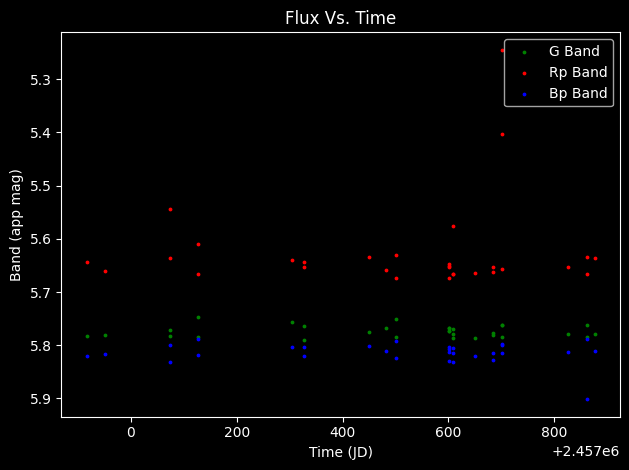

In [14]:
#Plot light curve unphased.
ephot.lightcurve(df)

Best period: 0.139890 days (3.357 hours)
1. Period: 0.139890 days (3.357 hours), Power: 0.751746, FAP: 3.269611736969218e-06
2. Period: 0.139894 days (3.357 hours), Power: 0.700077, FAP: 3.6865080302873306e-05
3. Period: 0.139886 days (3.357 hours), Power: 0.696102, FAP: 4.362451770217136e-05
4. Period: 0.138441 days (3.323 hours), Power: 0.663091, FAP: 0.0001627191348461431
5. Period: 0.135147 days (3.244 hours), Power: 0.638587, FAP: 0.00039779158434609266


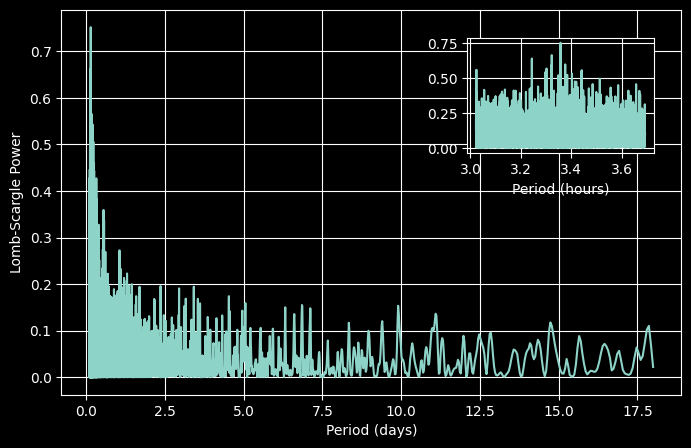

In [32]:
period = ephot.lomb_scargle(df['g_transit_time'], df['g_transit_mag'], period_range = [0.1, 18], plot = True)

Len g, bp, and rp datasets respectively: 30, 30, 30
P value: 0.1398899083976576


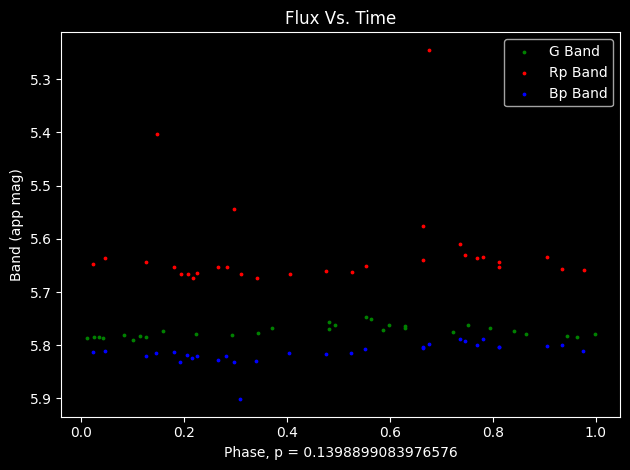

In [33]:
#Plot light curve phased:
ephot.lightcurve(df, period = period)